In [2]:
import re
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from collections import defaultdict
from scipy import stats
from turker_eval_lib import *

In [3]:
pd.options.display.max_columns = None

### Load turker results

In [4]:
path = "../connectives_turkers_results_all.csv"
df_turkers = pd.read_csv(path)

max_batches = int((len(df_turkers) / 9) + 1) # 9 is number of workers per problem, +1 is to work with range(1,max_batches)
# Seperate same worker doing two different batches

worker_ids = []
remaining = ["tmp"]
while not len(remaining) == 0:
    remaining = []
    worker_ids = []
    for index, row in df_turkers.iterrows():
        worker = df_turkers.loc[index, "WorkerId"]
        if not worker in worker_ids:
            worker_ids.append(worker)
        else:
            df_turkers.loc[index,"WorkerId"] = str(worker) + "_SECOND"
            worker = df_turkers.loc[index, "WorkerId"]
            worker_ids.append(worker)
            remaining.append(worker)

#add num answered to df
if "num_answered" in df_turkers.columns:
    df_turkers = df_turkers.drop('num_answered', axis=1)
df_turkers.insert(column="num_answered", loc=len(df_turkers.columns), value=0)

# df.insert(column="nones", loc=len(df.columns), value=0)

prev_seen = set()

for batch in range(1,max_batches): #six batches
    answers = get_answers(get_abs_batch(df_turkers, batch))
    
    q_sets = (len(answers.columns) - 1) // 2 #minus 1 for worker ids, div by 2 b/c two questions for each 'choice'
    questions = answers.columns[1:]

    for i in range(q_sets):

        q1 = questions[2 * i]
        q2 = questions[2 * i + 1]
        
        for worker in answers["WorkerId"]:
            worker_df = df_turkers.loc[df_turkers["WorkerId"] == worker]
            if (not (worker_df[q1].values[0] == worker_df[q2].values[0])):
                df_turkers.loc[df_turkers["WorkerId"] == worker, "num_answered"] += 1

#calculate agreements
all_agreements = {}
all_agreements_scores = []
for batch in range(1, max_batches):
    all_agreements.update(agreement(df_turkers, batch))

# add agreement rate to df
df_turkers.insert(column="agreement", loc=len(df_turkers.columns), value=None)
for worker in all_agreements.keys():
    df_turkers.loc[df_turkers["WorkerId"] == str(worker), "agreement"] = (all_agreements[worker] / 25)
df_turkers['agreement'] = df_turkers['agreement'].astype(float)

drop_percent = 20

fastest = set(find_bottom(df_turkers, "WorkTimeInSeconds", "WorkerId", drop_percent))
disagreers = set(find_bottom(df_turkers, "agreement", "WorkerId", drop_percent))
indecisives = set(find_bottom(df_turkers, "num_answered", "WorkerId", drop_percent))

bottom_in_everything_set = fastest.union(indecisives).union(disagreers)

for worker in bottom_in_everything_set:
    df_turkers = df_turkers[df_turkers["WorkerId"] != worker]

In [5]:
# df_turkers.to_csv("df_turkers_prelimclean.csv")

In [6]:
all_questions = set()
for q in get_answers(df_turkers).columns[1:]:
    vals = q.split("_")
    item = int(vals[0].strip("Answers."))
    category = vals[2]
    all_questions.add((category, item))
len(all_questions)
print("First four:", list(all_questions)[0:4])

First four: [('instantiation', 9), ('instantiation', 18), ('temporal', 40), ('instantiation', 27)]


In [7]:
def get_consensus(category, item):
    df = get_q_answers(df_turkers, category, item)
    consensus_vals = df["Choice"].value_counts(dropna=False)
    
    freq_None = consensus_vals.get(None)
    freq_1 = consensus_vals.get(1)
    freq_2 = consensus_vals.get(2)

    if freq_None == None:
        freq_None = 0
    if freq_1 == None:
        freq_1 = 0
    if freq_2 == None:
        freq_2 = 0
    
    max = np.max([freq_None, freq_1, freq_2])
    consensus = pd.DataFrame(columns=["answer","inference","percent"])
    if max == -1:
        raise Exception("TODO: fix this if it ever happens")
    
    response_count = freq_1 + freq_2 + freq_None

    if max == freq_None:
        consensus.loc[len(consensus)] = ([None, None, freq_None / response_count])
    if max == freq_1:
        inference = df.columns[1].split("_")[6]
        consensus.loc[len(consensus)] = ([1, inference, freq_1 / response_count])
    if max == freq_2:
        inference = df.columns[2].split("_")[6]
        consensus.loc[len(consensus)] = ([2, inference, freq_2 / response_count])

    return consensus

In [8]:
get_consensus("preference", 167)

,answer,inference,percent
0,2,Wugsville has mountains.,0.571429


In [9]:
get_consensus("temporal", 164)

,answer,inference,percent
0,1,daxday occured after wugfest.,0.428571
1,2,wugfest occured after daxday.,0.428571


In [10]:
counter = 0
for category, item in all_questions:
    tmp = get_consensus(category, item)
    if len(tmp) > 1:
        # print(tmp["percent"].values[0])
        counter += 1
        print(category, item, list(tmp["answer"]))

print(counter)
print(round(counter / len(all_questions) * 100,4), "%", "have more than one answer")

temporal 40 [1, 2]
instantiation 27 [1, 2]
temporal 58 [1, 2]


temporal 35 [1, 2]
preference 102 [1, 2]
temporal 160 [1, 2]
preference 106 [1, 2]
preference 124 [1, 2]
temporal 137 [1, 2]
temporal 155 [1, 2]
temporal 164 [1, 2]
temporal 11 [1, 2]
preference 105 [1, 2]
preference 64 [1, 2]
preference 82 [1, 2]
temporal 145 [1, 2]
preference 189 [1, 2]
preference 63 [1, 2]
temporal 220 [nan, 1.0, 2.0]
preference 184 [1, 2]
preference 49 [1, 2]
preference 152 [1, 2]
preference 179 [1, 2]
temporal 116 [1, 2]
temporal 210 [nan, 1.0, 2.0]
preference 142 [1, 2]
preference 160 [1, 2]
preference 25 [1, 2]
temporal 200 [1, 2]
preference 155 [1, 2]
instantiation 7 [1, 2]
temporal 65 [1, 2]
temporal 55 [1, 2]
temporal 185 [1, 2]
temporal 23 [1, 2]
temporal 144 [1, 2]
temporal 162 [1, 2]
temporal 139 [1, 2]
temporal 13 [1, 2]
temporal 22 [1, 2]
temporal 134 [1, 2]
temporal 161 [1, 2]
preference 93 [1, 2]
temporal 115 [1, 2]
preference 173 [1, 2]
preference 38 [1, 2]
preference 65 [1, 2]
preference 159 [1, 2]
preference 177 [nan, 1.0]
preference 24 [1, 2]
prefe

### Load model results

In [11]:
path1 = "../outputs/babylm--babyllama-100m-2024_results.csv"
path2 = "../outputs/gpt2_results.csv"
path3 = "../outputs/meta-llama--Llama-3.1-8B_results.csv"
path4 = "../outputs/meta-llama--Llama-3.1-8B-Instruct_results.csv"
path5 = "../outputs/meta-llama--Llama-3.2-3B_results.csv"
path6 = "../outputs/mistralai--Mistral-7B-Instruct-v0.3_results.csv"
path7 = "../outputs/mistralai--Mistral-7B-v0.3_results.csv"
path8 = "../outputs/babylm--opt-125m-strict_results.csv"

df_babyllama = pd.read_csv(path1)
df_gpt2 = pd.read_csv(path2)
df_llama_3_8B = pd.read_csv(path3)
df_llama_3_8B_instruct = pd.read_csv(path4)
df_llama_3_2_3B_instruct = pd.read_csv(path5)
df_mistral_7B_instruct = pd.read_csv(path6)
df2_mistral_7B = pd.read_csv(path7)
df_babylm = pd.read_csv(path8)

all_modeldata = [ df_llama_3_8B, df_llama_3_8B_instruct, df_llama_3_2_3B_instruct, df_mistral_7B_instruct, df2_mistral_7B, df_babyllama, df_babylm, df_gpt2]
model_names =   ["llama_3_8B", "llama_3_8B_instruct", "llama_3_2_3B_instruct", "mistral_7B_instruct", "mistral_7B", "babyllama", "babylm","gpt2",]

In [12]:
def add_category_and_items(df:pd.DataFrame):
    if not "category" in df.columns:
        df.insert(2, "category", None)
    if not "item" in df.columns:
        df.insert(2, "item", None)
    
    for index, row in df.iterrows():
        premise = row["premise"]
        category = row["inference_id_A"].split("_")[2]
        item = row["inference_id_A"].split("_")[0]
        
        df.loc[df["premise"] == premise, "category"] = category
        df.loc[df["premise"] == premise, "item"] = item
        
    return

for df in all_modeldata:
    add_category_and_items(df)

In [13]:
df_mistral_7B_instruct.head(2)
# df_babyllama.head(2)

,Unnamed: 0,premise,item,category,inference_A,inference_id_A,inference_B,inference_id_B,nonce_A,nonce_B,prompt_QA,prompt_A_YN,prompt_B_YN,rating_QA_A,rating_QA_B,rating_A_YN_Y,rating_A_YN_N,rating_B_YN_Y,rating_B_YN_N
0,0,"I find feps such as blickets, to be cute.",38,instantiation,feps are instances of blickets.,38_8_instantiation_feps_such as_blickets_feps ...,blickets are instances of feps.,38_8_instantiation_feps_such as_blickets_blick...,feps,blickets,Given the following statement:\nI find feps su...,Given the following statement:\nI find feps su...,Given the following statement:\nI find feps su...,-2.393658,-1.916630,-1.799585,-3.022252,-1.081381,-9.365498
1,1,"daxday happened. Hence, fepfestival happened.",125,temporal,daxday occured before fepfestival.,125_5_temporal_daxday_hence_fepfestival_daxday...,fepfestival occured before daxday.,125_5_temporal_daxday_hence_fepfestival_fepfes...,daxday,fepfestival,Given the following statement:\ndaxday happene...,Given the following statement:\ndaxday happene...,Given the following statement:\ndaxday happene...,-1.473123,-1.110032,-4.052398,-2.599909,-5.521340,-1.984694


In [14]:
def add_model_choices_QA(df:pd.DataFrame):
    if not "QA_choice" in df.columns:
        df.insert(len(df.columns), "QA_choice", None)
    if not "QA_choice_inference" in df.columns:
        df.insert(len(df.columns), "QA_choice_inference", None)
    
    for index, row in df.iterrows():
        premise = row["premise"]

        answered_A = row["rating_QA_A"] > row["rating_QA_B"]
        if row["rating_QA_A"] == row["rating_QA_B"]:
            print("AAAAAAAAAAAAAAA")
        
        if answered_A:
            df.loc[df["premise"] == premise, "QA_choice"] = "A"
            df.loc[df["premise"] == premise, "QA_choice_inference"] = row["inference_A"]
        else:
            df.loc[df["premise"] == premise, "QA_choice"] = "B"
            df.loc[df["premise"] == premise, "QA_choice_inference"] = row["inference_B"]
    return

for df in all_modeldata:
    add_model_choices_QA(df)

In [15]:
def add_model_choices_YN(df:pd.DataFrame):
    if not "YN_choice" in df.columns:
        df.insert(len(df.columns), "YN_choice", None)
    if not "YN_choice_inference" in df.columns:
        df.insert(len(df.columns), "YN_choice_inference", None)
    
    for index, row in df.iterrows():
        premise = row["premise"]

        answered_A_yes = (row["rating_A_YN_Y"] > row["rating_A_YN_N"])
        answered_B_yes = (row["rating_B_YN_Y"] > row["rating_B_YN_N"])

        if answered_B_yes and answered_A_yes:
            if row["rating_A_YN_Y"] > row["rating_B_YN_Y"]:
                df.loc[df["premise"] == premise, "YN_choice"] = "A"
                df.loc[df["premise"] == premise, "YN_choice_inference"] = row["inference_A"]
            else:
                df.loc[df["premise"] == premise, "YN_choice"] = "B"
                df.loc[df["premise"] == premise, "YN_choice_inference"] = row["inference_B"]
            
        elif not(answered_B_yes or answered_A_yes):
            df.loc[df["premise"] == premise, "YN_choice"] = "neither"
            df.loc[df["premise"] == premise, "YN_choice_inference"] ="neither"
            
        elif answered_A_yes:
            df.loc[df["premise"] == premise, "YN_choice"] = "A"
            df.loc[df["premise"] == premise, "YN_choice_inference"] = row["inference_A"]
        else: # answered_B_yes
            df.loc[df["premise"] == premise, "YN_choice"] = "B"
            df.loc[df["premise"] == premise, "YN_choice_inference"] = row["inference_B"]
    return

for df in all_modeldata:
    add_model_choices_YN(df)

In [16]:
def add_model_choices_YN_strict(df:pd.DataFrame):
    if not "YN_choice" in df.columns:
        df.insert(len(df.columns), "YN_choice", None)
    if not "YN_choice_inference" in df.columns:
        df.insert(len(df.columns), "YN_choice_inference", None)
    
    for index, row in df.iterrows():
        premise = row["premise"]
        
        answered_A_yes = (row["rating_A_YN_Y"] > row["rating_A_YN_N"])
        answered_B_yes = (row["rating_B_YN_Y"] > row["rating_B_YN_N"])
        
        
        if answered_B_yes and answered_A_yes:
            df.loc[df["premise"] == premise, "YN_strict_choice"] = "both"
            df.loc[df["premise"] == premise, "YN_strict_choice_inference"] ="both"
        elif not(answered_B_yes or answered_A_yes):
            df.loc[df["premise"] == premise, "YN_strict_choice"] = "neither"
            df.loc[df["premise"] == premise, "YN_strict_choice_inference"] ="neither"
        elif answered_A_yes:
            df.loc[df["premise"] == premise, "YN_strict_choice"] = "A"
            df.loc[df["premise"] == premise, "YN_strict_choice_inference"] = row["inference_A"]
        else: # answered_B_yes
            df.loc[df["premise"] == premise, "YN_strict_choice"] = "B"
            df.loc[df["premise"] == premise, "YN_strict_choice_inference"] = row["inference_B"]
    return

for df in all_modeldata:
    add_model_choices_YN_strict(df)

In [17]:
for df in all_modeldata:
    if not "agree_w_human_QA" in df.columns:
        df.insert(len(df.columns), "agree_w_human_QA", 0)
    if not "agree_w_human_YN_strict" in df.columns:
        df.insert(len(df.columns), "agree_w_human_YN_strict", 0)
    if not "agree_w_human_YN" in df.columns:
        df.insert(len(df.columns), "agree_w_human_YN", 0)

In [18]:
df_mistral_7B_instruct.head(2)
# df_babyllama.head(3)

,Unnamed: 0,premise,item,category,inference_A,inference_id_A,inference_B,inference_id_B,nonce_A,nonce_B,prompt_QA,prompt_A_YN,prompt_B_YN,rating_QA_A,rating_QA_B,rating_A_YN_Y,rating_A_YN_N,rating_B_YN_Y,rating_B_YN_N,QA_choice,QA_choice_inference,YN_choice,YN_choice_inference,YN_strict_choice,YN_strict_choice_inference,agree_w_human_QA,agree_w_human_YN_strict,agree_w_human_YN
0,0,"I find feps such as blickets, to be cute.",38,instantiation,feps are instances of blickets.,38_8_instantiation_feps_such as_blickets_feps ...,blickets are instances of feps.,38_8_instantiation_feps_such as_blickets_blick...,feps,blickets,Given the following statement:\nI find feps su...,Given the following statement:\nI find feps su...,Given the following statement:\nI find feps su...,-2.393658,-1.916630,-1.799585,-3.022252,-1.081381,-9.365498,B,blickets are instances of feps.,B,blickets are instances of feps.,both,both,0,0,0
1,1,"daxday happened. Hence, fepfestival happened.",125,temporal,daxday occured before fepfestival.,125_5_temporal_daxday_hence_fepfestival_daxday...,fepfestival occured before daxday.,125_5_temporal_daxday_hence_fepfestival_fepfes...,daxday,fepfestival,Given the following statement:\ndaxday happene...,Given the following statement:\ndaxday happene...,Given the following statement:\ndaxday happene...,-1.473123,-1.110032,-4.052398,-2.599909,-5.521340,-1.984694,B,fepfestival occured before daxday.,neither,neither,neither,neither,0,0,0


In [19]:
for model in all_modeldata:
    for category, item in all_questions:
        consensus = get_consensus(category, item)
        
        human_answers = consensus["inference"]
        human_percents = consensus["percent"] 

        model_answer_QA = model.loc[((model["item"] == str(item)) & (model["category"] == category)), "QA_choice_inference"].values
        model_answer_YN = model.loc[((model["item"] == str(item)) & (model["category"] == category)), "YN_choice_inference"].values
        model_answer_YN_strict = model.loc[((model["item"] == str(item)) & (model["category"] == category)), "YN_strict_choice_inference"].values
        
        # did the humans answer with both inferences? 
        # (the second portion of the 'and' is "if the humans answered two values were acceptable, 'No Choice' was not one of them")
        human_answer_both = (len(human_answers.values) > 1) and ((len(human_answers.values) == 2) or (not math.nan in human_answers.values))
         # These conditions are true if: 
            #   A) the model picked a value that the humans picked, or 
            #   B) the humans picked both and the model picked both as well
        
        if (model_answer_QA in human_answers.values) or (model_answer_QA == "both" and human_answer_both):
            model.loc[((model["item"] == str(item)) & (model["category"] == category)), "agree_w_human_QA"] = 1
        
        if (model_answer_YN in human_answers.values) or (model_answer_YN == "both" and human_answer_both):
            model.loc[((model["item"] == str(item)) & (model["category"] == category)), "agree_w_human_YN"] = 1
            
        if (model_answer_YN_strict in human_answers.values) or (model_answer_YN_strict == "both" and human_answer_both):
            model.loc[((model["item"] == str(item)) & (model["category"] == category)), "agree_w_human_YN_strict"] = 1

        
        model.loc[((model["item"] == str(item)) & (model["category"] == category)), "human_percent"] = np.min(list(human_percents.values))
            

In [20]:
def print_model_accuracies(all_modeldata, model_names, category="all", minpercent=0.0):    
    for model, name in zip(all_modeldata, model_names):
        model_alt = None
        if not category == "all":
            model_alt = model.loc[(model["category"] == category) & (model["human_percent"] >= minpercent)]
        else:
            model_alt = model.loc[model["human_percent"] >= (minpercent)]
       
        print(len(model_alt.loc[model_alt["agree_w_human"] == 1]), "\t", round(len(model_alt.loc[model_alt["agree_w_human"] == 1]) / len(model_alt) * 100, 2), "%\t", name, )

In [21]:
def model_accuracies(all_modeldata, model_names, category="all", minpercent=0.0, prompt_style="QA"):
    accs = pd.DataFrame(columns=["models","percent","absolute_num", "total"])
    for model, name in zip(all_modeldata, model_names):
        model_alt = None
        if not category == "all":
            model_alt = model.loc[(model["category"] == category) & (model["human_percent"] >= minpercent)]
        else:
            model_alt = model.loc[model["human_percent"] >= (minpercent)]
        
        agree_w_human = "agree_w_human_" + prompt_style
        
        percent = len(model_alt.loc[model_alt[agree_w_human] == 1]) / len(model_alt)
        absolute_num = len(model_alt.loc[model_alt[agree_w_human] == 1])
        total = len(model_alt)
        
        # print(len(model_alt.loc[model_alt["agree_w_human"] == 1]), "\t", round(len(model_alt.loc[model_alt["agree_w_human"] == 1]) / len(model_alt) * 100, 2), "%\t", name, )
        accs.loc[len(accs)] = [name, str(round(percent * 100, 2)) + "%", absolute_num, total]
    
    return accs


model_accuracies(all_modeldata, model_names, minpercent=0, prompt_style="YN")

,models,percent,absolute_num,total
0,llama_3_8B,55.33%,249,450
1,llama_3_8B_instruct,31.33%,141,450
2,llama_3_2_3B_instruct,56.22%,253,450
3,mistral_7B_instruct,53.33%,240,450
4,mistral_7B,63.78%,287,450
5,babyllama,0.0%,0,450
6,babylm,30.0%,135,450
7,gpt2,53.78%,242,450


In [22]:
def plot_accs(accs, title="Model Accuracy", color=None):
    y = accs["absolute_num"]
    x = accs["models"]
    bar_labels = accs["percent"]

    max = accs["total"][0]
    plt.axhline(y=max,color="w") 
    bar = plt.bar(x, y, color=color)

    for b, label in zip(bar, bar_labels):
        height = b.get_height()
        plt.text(b.get_x() + b.get_width() / 2.0, height, label, ha='center', va='bottom', fontsize=9, fontweight="roman")

    plt.xticks(rotation=-30, ha="left", va="top", rotation_mode="anchor")
    range = np.append(np.arange(0, max, 50).tolist(), max)
    plt.yticks(range)

    plt.title(title)
    plt.xlabel("Model Name")
    plt.ylabel("Number Correct")

    plt.show()

In [23]:
minpercent = 0.0
prompt_style = "QA"

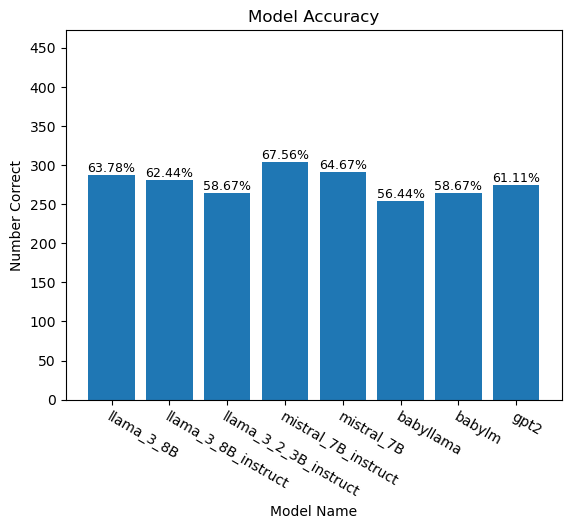

In [24]:
accs = model_accuracies(all_modeldata, model_names, prompt_style=prompt_style, minpercent=minpercent)
plot_accs(accs)

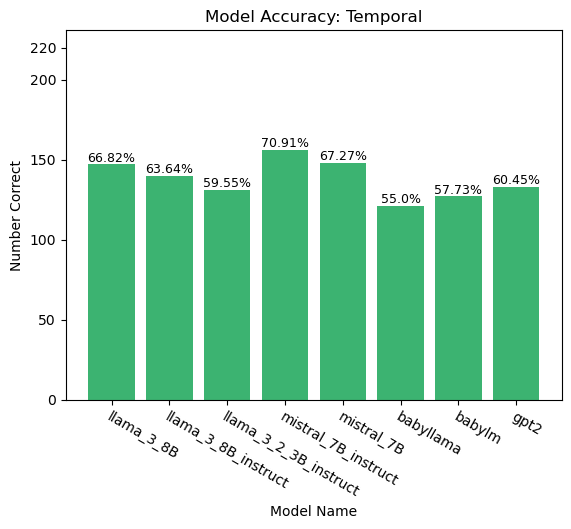

In [25]:
accs_temp = model_accuracies(all_modeldata, model_names, category="temporal", prompt_style=prompt_style, minpercent=minpercent)
plot_accs(accs_temp, title="Model Accuracy: Temporal", color="mediumseagreen")

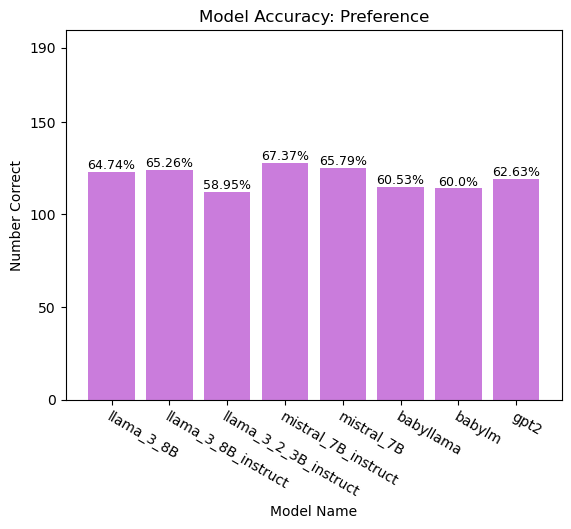

In [26]:
accs_pref = model_accuracies(all_modeldata, model_names, category="preference", prompt_style=prompt_style, minpercent=minpercent)
plot_accs(accs_pref, title="Model Accuracy: Preference", color="#CA7CDC")

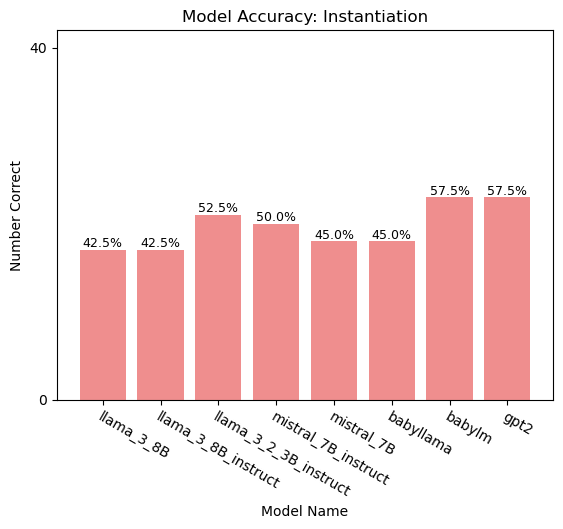

In [27]:
accs_inst = model_accuracies(all_modeldata, model_names, category="instantiation", prompt_style=prompt_style, minpercent=minpercent)
plot_accs(accs_inst, title="Model Accuracy: Instantiation", color="#EF8E8E")

In [28]:
df_differences = pd.DataFrame(columns=None, index=range(len(df_babyllama)))
for model, name in zip(all_modeldata, model_names):
    df_differences["rating_QA_A_" + name] = model["rating_QA_A"]
    df_differences["rating_QA_B_" + name] = model["rating_QA_B"]

    df_differences[name + "_diff"] = (np.array(model["rating_QA_A"]) - np.array(model["rating_QA_B"]))
    print(np.mean(df_differences[name + "_diff"]), "\t", name)
# df_differences.head()

0.1023169215520223 	 llama_3_8B
0.21111643857426113 	 llama_3_8B_instruct
0.09875409947501289 	 llama_3_2_3B_instruct
0.058071419563558366 	 mistral_7B_instruct
0.06610010279549493 	 mistral_7B
0.0716424534055922 	 babyllama
0.320964269373152 	 babylm
0.2147017028596666 	 gpt2


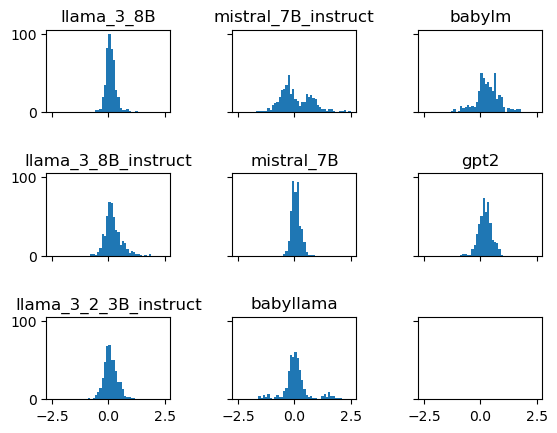

In [29]:
pltwidth = 3
pltheight= 3
fig, axes = plt.subplots(pltwidth, pltheight, sharex=True, sharey=True)

plt.subplots_adjust(wspace=.5, hspace=.75)

pltx = 0
plty = 0

for model, name in zip(all_modeldata, model_names):
    y = np.sort(df_differences[name + "_diff"])
    
    # axes[pltx, plty].axvline(0, color="black", linestyle="dotted")
    # axes[pltx, plty].text(x=-1.2, y=35, s="Prefers B\nInference",ha="center")
    # axes[pltx, plty].text(x= 1.2, y=35, s="Prefers A\nInference",ha="center")
    # axes[pltx, plty].xticks(np.arange(-2.5, 2.51, .5))
    
    axes[pltx, plty].hist(y,bins=50,range=(-2.5,2.5))
    axes[pltx, plty].set_title(name)
    
    
    pltx += 1
    if pltx >= pltwidth:
        pltx = 0
        plty += 1
        
plt.show()

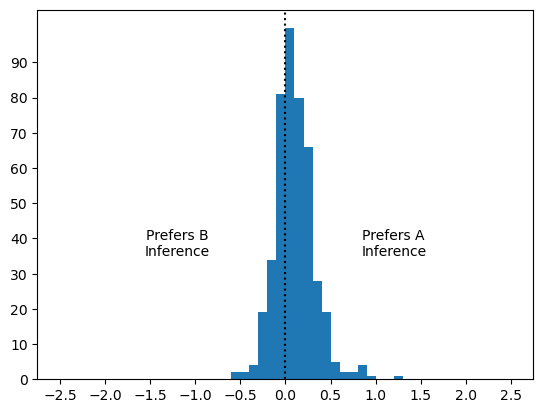

In [30]:
name = "llama_3_8B"

y = np.sort(df_differences[name + "_diff"])

plt.axvline(0, color="black", linestyle="dotted")
plt.text(x=-1.2, y=35, s="Prefers B\nInference",ha="center")
plt.text(x= 1.2, y=35, s="Prefers A\nInference",ha="center")

plt.xticks(np.arange(-2.5, 2.51, .5))
plt.yticks(np.arange(0, 100, 10))

plt.axhline(100, color="w") # artificially ensure all graphs have the same height, for comparison

plt.hist(y,bins=50,range=(-2.5,2.5))
plt.show()

In [31]:
print(np.max(df_differences[name + "_diff"]))
print(np.min(df_differences[name + "_diff"]))


1.2682167291641238
-0.5567902326583865


In [32]:
df_babyllama.head(3)

,Unnamed: 0,premise,item,category,inference_A,inference_id_A,inference_B,inference_id_B,nonce_A,nonce_B,prompt_QA,prompt_A_YN,prompt_B_YN,rating_QA_A,rating_QA_B,rating_A_YN_Y,rating_A_YN_N,rating_B_YN_Y,rating_B_YN_N,QA_choice,QA_choice_inference,YN_choice,YN_choice_inference,YN_strict_choice,YN_strict_choice_inference,agree_w_human_QA,agree_w_human_YN_strict,agree_w_human_YN,human_percent
0,0,"I find feps such as blickets, to be cute.",38,instantiation,feps are instances of blickets.,38_8_instantiation_feps_such as_blickets_feps ...,blickets are instances of feps.,38_8_instantiation_feps_such as_blickets_blick...,feps,blickets,Given the following statement:\nI find feps su...,Given the following statement:\nI find feps su...,Given the following statement:\nI find feps su...,-4.426517,-4.262149,-13.161870,-11.657465,-13.082719,-11.538742,B,blickets are instances of feps.,neither,neither,neither,neither,0,0,0,0.750000
1,1,"daxday happened. Hence, fepfestival happened.",125,temporal,daxday occured before fepfestival.,125_5_temporal_daxday_hence_fepfestival_daxday...,fepfestival occured before daxday.,125_5_temporal_daxday_hence_fepfestival_fepfes...,daxday,fepfestival,Given the following statement:\ndaxday happene...,Given the following statement:\ndaxday happene...,Given the following statement:\ndaxday happene...,-4.672937,-4.776929,-13.202126,-11.610996,-13.191441,-11.604681,A,daxday occured before fepfestival.,neither,neither,neither,neither,0,0,0,0.583333
2,2,gekxtravaganza happened even before wugfest.,91,temporal,wugfest occured before gekxtravaganza.,91_1_temporal_wugfest_even before_gekxtravagan...,gekxtravaganza occured before wugfest.,91_1_temporal_wugfest_even before_gekxtravagan...,wugfest,gekxtravaganza,Given the following statement:\ngekxtravaganza...,Given the following statement:\ngekxtravaganza...,Given the following statement:\ngekxtravaganza...,-4.137755,-3.499108,-12.699673,-10.978760,-12.711307,-10.921936,B,gekxtravaganza occured before wugfest.,neither,neither,neither,neither,0,0,0,0.583333


In [ ]:
# generate clean turker dataset by bootstrapping model info haha

columns = ["premise","category","item","inference_A", "inference_id_A", "inference_B", "inference_id_B", "nonce_A",
           "nonce_B", "answer_1_inference","answer_2_inference","answer_3_inference","answer_percent", "answers_list", "workers_list"]
df_turker_byquestion = pd.DataFrame(columns=columns)

df_turker_byquestion = df_turker_byquestion.astype({"workers_list":object, "answers_list":object})
# df_turker_byquestion.astype("workers_list", object)

# add category, item
df_turker_byquestion["category"] = df_babyllama["category"].copy()
df_turker_byquestion["item"] = df_babyllama["item"].copy()

# add infrences + premise
df_turker_byquestion["premise"] = df_babyllama["premise"].copy()
df_turker_byquestion["inference_A"] = df_babyllama["inference_A"].copy()
df_turker_byquestion["inference_B"] = df_babyllama["inference_B"].copy()
df_turker_byquestion["inference_id_A"] = df_babyllama["inference_id_A"].copy()
df_turker_byquestion["inference_id_B"] = df_babyllama["inference_id_B"].copy()

#add nonces
df_turker_byquestion["nonce_A"] = df_babyllama["nonce_A"].copy()
df_turker_byquestion["nonce_B"] = df_babyllama["nonce_B"].copy()

#set default values for answers
df_turker_byquestion.fillna("No other picked", inplace=True)

for category, item in all_questions:
    consensus = get_consensus(category, item)
    for index, row in consensus.iterrows():
        answer_num = "answer_" + str(index + 1) + "_inference"
        answer = row["inference"]

        df_turker_byquestion.loc[(df_turker_byquestion["category"] == category) & (df_turker_byquestion["item"] == str(item)), answer_num] = answer
        
    df_turker_byquestion.loc[(df_turker_byquestion["category"] == category) & (df_turker_byquestion["item"] == str(item)), "answer_percent"] = consensus["percent"].values[0]
    q_consensus = get_q_consensus(df_turkers, category, item)

    df_turker_byquestion.loc[(df_turker_byquestion["category"] == category) & (df_turker_byquestion["item"] == str(item)), "answers_list"] = str((list(q_consensus["Choice"])))
    df_turker_byquestion.loc[(df_turker_byquestion["category"] == category) & (df_turker_byquestion["item"] == str(item)), "workers_list"] = str((list(q_consensus["WorkerId"])))


In [64]:
df_turker_byquestion.head(2)
df_turker_byquestion.to_csv("turker_response_by_question.csv")